# TOG Attacks on YOLOv3 (Darknet53) — PyTorch

Self-contained PyTorch reimplementation (no Keras / no `thirdparty` imports).
- Model / detect: `yolov3_model.py`
- TOG losses / gradients: `loss_extractor.py`
- Attacks: `tog_attacks.py`
- Helpers: `utils.py`


## Preparation of Victim Detector


In [1]:
from pathlib import Path
from PIL import Image

import numpy as np

from tog_model import YOLOv3TOGModel
from tog_attacks import (
    tog_fabrication,
    tog_mislabeling,
    tog_untargeted,
    tog_vanishing,
)
from utils import letterbox_image, visualize_detections
from yolov3_model import YOLOv3Detector

ROOT = Path('.').resolve()


Load the detector from local Darknet weights (`weights/yolov3.weights`).


In [2]:
# Đổi 'weights' thành 'model' nếu file yolov3.weights nằm trong thư mục model/
weights = ROOT / 'model' / 'yolov3.weights'  

detector = YOLOv3Detector(weights=weights)
victim = YOLOv3TOGModel(detector)

print('device:', detector.device)
print('num classes:', detector.num_classes)

device: cuda
num classes: 80


## Configuration of Attack Hyperparameters


Load and visualize the image to be attacked.


Đang chạy thử nghiệm trên ảnh: 000000127135.jpg


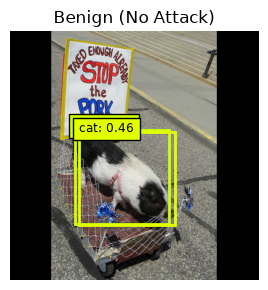

Benign detections count: 2


In [3]:
import random

epsilon = 8 / 255.       # Maximum L-infinity perturbation
step_size = 2 / 255.     # Per-iteration update size
num_iterations = 10      # Number of attack iterations

# Tự động quét thư mục val2017
data_dir = ROOT / 'data' / 'coco' / 'val2017'
image_files = sorted(list(data_dir.glob('*.jpg')) + list(data_dir.glob('*.png')))

if not image_files:
    raise FileNotFoundError(f"Không tìm thấy ảnh nào trong thư mục: {data_dir}")

# Lấy ngẫu nhiên 1 ảnh từ danh sách
image_path = random.choice(image_files)
print(f"Đang chạy thử nghiệm trên ảnh: {image_path.name}")

input_img = Image.open(image_path).convert('RGB')

x_query, x_meta = letterbox_image(input_img, size=detector.model_image_size)
detections_query = detector.detect(x_query, confidence_threshold=detector.confidence_threshold)

visualize_detections({
    'Benign (No Attack)': (x_query, detections_query, detector.model_image_size, detector.class_names)
})
print('Benign detections count:', len(detections_query))

## TOG-untargeted Attack

Random untargeted attacks fool the victim detector to randomly misdetect without targeting any specific object.


Detections count after TOG-untargeted: 7


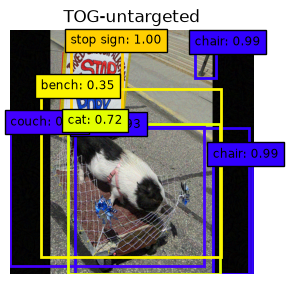

In [4]:
# 1. Thực hiện tấn công TOG Untargeted
adv_untargeted = tog_untargeted(
    victim=victim,
    image=x_query,
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)

# 2. Chạy nhận diện trên ảnh đối kháng
detections_untargeted = detector.detect(adv_untargeted, confidence_threshold=detector.confidence_threshold)
print('Detections count after TOG-untargeted:', len(detections_untargeted))

# 3. Trực quan hóa kết quả
visualize_detections({
    'TOG-untargeted': (adv_untargeted, detections_untargeted, detector.model_image_size, detector.class_names)
})

## TOG-vanishing Attack

TOG-vanishing aims at removing the victim's ability to identify objects (false negatives).


Detections count after TOG-vanishing: 0


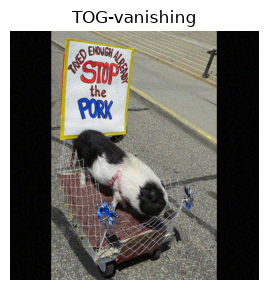

In [5]:
# 1. Thực hiện tấn công TOG Vanishing (làm biến mất vật thể)
adv_vanishing = tog_vanishing(
    victim=victim,
    image=x_query,
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)

# 2. Chạy nhận diện trên ảnh đối kháng
detections_vanishing = detector.detect(adv_vanishing, confidence_threshold=detector.confidence_threshold)
print('Detections count after TOG-vanishing:', len(detections_vanishing))

# 3. Trực quan hóa kết quả
visualize_detections({
    'TOG-vanishing': (adv_vanishing, detections_vanishing, detector.model_image_size, detector.class_names)
})

## TOG-fabrication Attack

TOG-fabrication fabricates additional detections (false positives).


Detections count after TOG-fabrication: 76


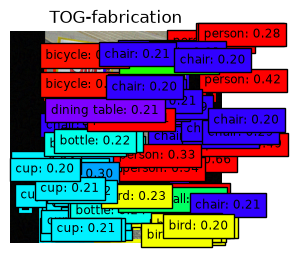

In [6]:
# 1. Thực hiện tấn công TOG Fabrication (tạo vật thể giả)
adv_fabrication = tog_fabrication(
    victim=victim,
    image=x_query,
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)

# 2. Chạy nhận diện trên ảnh đối kháng
detections_fabrication = detector.detect(adv_fabrication, confidence_threshold=detector.confidence_threshold)
print('Detections count after TOG-fabrication:', len(detections_fabrication))

# 3. Trực quan hóa kết quả
visualize_detections({
    'TOG-fabrication': (adv_fabrication, detections_fabrication, detector.model_image_size, detector.class_names)
})

## TOG-mislabeling Attack

Most-likely (ML) and least-likely (LL) class mislabeling attacks.


Detections count (Most-Likely): 1
Detections count (Least-Likely): 3


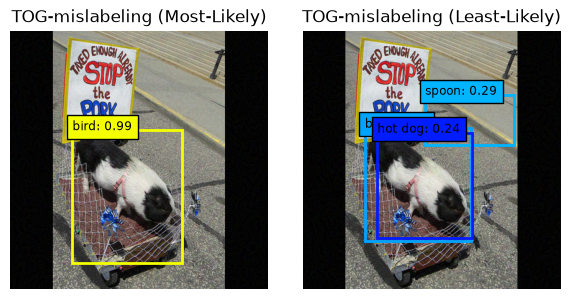

In [7]:
# 1. Tấn công Mislabeling dạng Most-Likely (ML)
adv_mislabeling_ml = tog_mislabeling(
    victim=victim,
    image=x_query,
    target="most_likely",
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)
detections_mislabeling_ml = detector.detect(adv_mislabeling_ml, confidence_threshold=detector.confidence_threshold)

# 2. Tấn công Mislabeling dạng Least-Likely (LL)
adv_mislabeling_ll = tog_mislabeling(
    victim=victim,
    image=x_query,
    target="least_likely",
    num_iterations=num_iterations,
    epsilon=epsilon,
    step_size=step_size
)
detections_mislabeling_ll = detector.detect(adv_mislabeling_ll, confidence_threshold=detector.confidence_threshold)

print('Detections count (Most-Likely):', len(detections_mislabeling_ml))
print('Detections count (Least-Likely):', len(detections_mislabeling_ll))

# 3. Trực quan hóa kết quả cả 2 trường hợp
visualize_detections({
    'TOG-mislabeling (Most-Likely)': (adv_mislabeling_ml, detections_mislabeling_ml, detector.model_image_size, detector.class_names),
    'TOG-mislabeling (Least-Likely)': (adv_mislabeling_ll, detections_mislabeling_ll, detector.model_image_size, detector.class_names)
})

Tổng hợp Chỉ số

In [8]:

from tabulate import tabulate

def calc_psnr(clean, adv):
    mse = np.mean((adv - clean) ** 2)
    return 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else float('inf')

all_results = [
    ["Benign", len(detections_query), 0.0, "N/A"],
    ["TOG-untargeted", len(detections_untargeted), np.max(np.abs(adv_untargeted - x_query)) * 255, f"{calc_psnr(x_query, adv_untargeted):.2f} dB"],
    ["TOG-vanishing", len(detections_vanishing), np.max(np.abs(adv_vanishing - x_query)) * 255, f"{calc_psnr(x_query, adv_vanishing):.2f} dB"],
    ["TOG-fabrication", len(detections_fabrication), np.max(np.abs(adv_fabrication - x_query)) * 255, f"{calc_psnr(x_query, adv_fabrication):.2f} dB"],
    ["TOG-mislabeling (ML)", len(detections_mislabeling_ml), np.max(np.abs(adv_mislabeling_ml - x_query)) * 255, f"{calc_psnr(x_query, adv_mislabeling_ml):.2f} dB"],
    ["TOG-mislabeling (LL)", len(detections_mislabeling_ll), np.max(np.abs(adv_mislabeling_ll - x_query)) * 255, f"{calc_psnr(x_query, adv_mislabeling_ll):.2f} dB"],
]

print(tabulate(all_results, headers=["Attack Strategy", "Detections Left", "L_inf Perturbation", "PSNR"], tablefmt="fancy_grid"))

╒══════════════════════╤═══════════════════╤══════════════════════╤══════════╕
│ Attack Strategy      │   Detections Left │   L_inf Perturbation │ PSNR     │
╞══════════════════════╪═══════════════════╪══════════════════════╪══════════╡
│ Benign               │                 2 │              0       │ N/A      │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-untargeted       │                 7 │              8.00001 │ 33.96 dB │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-vanishing        │                 0 │              8.00001 │ 34.07 dB │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-fabrication      │                76 │              8.00001 │ 33.91 dB │
├──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ TOG-mislabeling (ML) │                 1 │              8.00001 │ 34.17 dB │
├──────────────────────┼───────────────────┼────────

TOG-universal Attack

In [9]:
## TOG-universal Attack

from tog_attacks import tog_universal

# 1. Đường dẫn tới thư mục val2017 chứa các ảnh COCO
val_data_path = str(ROOT / 'data' / 'coco' / 'val2017')

print("--- Đang huấn luyện Nhiễu Toàn Cục (Universal Adversarial Perturbation) ---")

# 2. Sinh nhiễu toàn cục (Universal Perturbation) từ tập ảnh COCO
# n_train_samples: Số lượng ảnh trích xuất để tạo nhiễu (có thể chỉnh lên 50 hoặc 100 nếu muốn nhiễu mạnh hơn)
universal_noise = tog_universal(
    victim=victim,
    image=x_query,
    num_iterations=5,      # Số epoch huấn luyện nhiễu
    epsilon=epsilon,
    step_size=step_size,
    data_path=val_data_path,
    n_train_samples=500     # Lấy 5000 ảnh mẫu trong val2017 để huấn luyện
)

# 3. Cộng nhiễu toàn cục vào ảnh truy vấn (x_query) và giới hạn giá trị pixel [0, 1]
adv_universal = np.clip(x_query + universal_noise, 0.0, 1.0)

# 4. Chạy mô hình nhận diện trên ảnh đã gắn nhiễu toàn cục
detections_universal = detector.detect(adv_universal, confidence_threshold=detector.confidence_threshold)

print(f'Số lượng vật thể ban đầu: {len(detections_query)}')
print(f'Số lượng vật thể sau tấn công TOG-universal: {len(detections_universal)}')

# 5. Hiển thị hình ảnh kết quả
visualize_detections({
    'TOG-universal': (adv_universal, detections_universal, detector.model_image_size, detector.class_names)
})

--- Đang huấn luyện Nhiễu Toàn Cục (Universal Adversarial Perturbation) ---


Epoch 2/5:  98%|█████████▊| 489/500 [00:26<00:00, 18.54it/s]


KeyboardInterrupt: 

COCO EVALUATION FUNCTION (OPTIMIZED)

In [15]:
def evaluate_coco_map(
    detector,
    coco_root,
    split='val2017',
    max_images=50,
    confidence_threshold=0.001,
    attack=None,
    victim=None,
    **attack_kwargs
):
    coco_root = Path(coco_root)
    ann_file = coco_root / 'annotations' / f'instances_{split}.json'
    img_dir = coco_root / split

    if not ann_file.exists():
        raise FileNotFoundError(f"Không tìm thấy file nhãn COCO: {ann_file}")

    coco_gt = COCO(str(ann_file))
    cat_ids = sorted(coco_gt.getCatIds())
    img_ids = sorted(coco_gt.getImgIds())
    
    if max_images is not None:
        img_ids = img_ids[:max_images]

    coco_results = []
    psnr_list = []
    exec_times = []
    
    model_w, model_h = detector.model_image_size

    print(f"Đang xử lý đánh giá trên {len(img_ids)} ảnh...")
    for idx, img_id in enumerate(img_ids, start=1):
        if idx % 10 == 0 or idx == len(img_ids):
            print(f"  • Tiến độ: {idx}/{len(img_ids)} ảnh", end='\r')

        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = img_dir / img_info['file_name']
        if not img_path.exists():
            continue

        orig_w, orig_h = img_info['width'], img_info['height']
        input_img = Image.open(img_path).convert('RGB')
        x_query, _ = letterbox_image(input_img, size=detector.model_image_size)

        # Tỉ lệ scale và padding từ letterbox
        scale = min(model_w / orig_w, model_h / orig_h)
        pad_x = (model_w - orig_w * scale) / 2.0
        pad_y = (model_h - orig_h * scale) / 2.0

        # Tấn công tạo ảnh đối kháng (nếu có)
        start_time = time.time()
        if attack is not None and victim is not None:
            try:
                x_input = attack(victim=victim, image=x_query, **attack_kwargs)
            except Exception as e:
                # --- ĐIỂM SỬA QUAN TRỌNG: IN RA LỖI ĐỂ FIX ---
                print(f"\n[CẢNH BÁO] Lỗi tấn công tại ảnh ID {img_id}: {e}")
                x_input = x_query
        else:
            x_input = x_query
        elapsed = time.time() - start_time

        if attack is not None:
            psnr_list.append(calculate_psnr(x_query, x_input))
            exec_times.append(elapsed)

        # Thực hiện dự đoán
        detections = detector.detect(x_input, confidence_threshold=confidence_threshold)
        if detections is None or len(detections) == 0:
            continue

        for det in detections:
            if hasattr(det, 'cpu'):
                det = det.cpu().numpy()

            class_id = int(det[0])
            score = float(det[1])
            
            # Thứ tự [xmin, ymin, xmax, ymax]
            xmin_m, ymin_m, xmax_m, ymax_m = float(det[-4]), float(det[-3]), float(det[-2]), float(det[-1])

            # Khôi phục tọa độ về ảnh gốc (loại bỏ padding letterbox)
            xmin_orig = max(0.0, (xmin_m - pad_x) / scale)
            ymin_orig = max(0.0, (ymin_m - pad_y) / scale)
            xmax_orig = min(float(orig_w), (xmax_m - pad_x) / scale)
            ymax_orig = min(float(orig_h), (ymax_m - pad_y) / scale)

            w_orig = max(0.0, xmax_orig - xmin_orig)
            h_orig = max(0.0, ymax_orig - ymin_orig)

            # Chuyển class index (0-79) sang category_id chuẩn COCO (1-90)
            coco_cat_id = cat_ids[class_id] if class_id < len(cat_ids) else class_id

            coco_results.append({
                "image_id": img_id,
                "category_id": coco_cat_id,
                "bbox": [xmin_orig, ymin_orig, w_orig, h_orig],
                "score": score
            })

    metrics = {"mAP (0.50:0.95)": 0.0, "mAP@50": 0.0, "mAP@75": 0.0, 
               "mAP (Small)": 0.0, "mAP (Medium)": 0.0, "mAP (Large)": 0.0,
               "Avg_PSNR": float(np.mean(psnr_list)) if psnr_list else 0.0,
               "Avg_Time": float(np.mean(exec_times)) if exec_times else 0.0}

    if not coco_results:
        print("\nKhông phát hiện ra vật thể nào!")
        return metrics

    coco_dt = coco_gt.loadRes(coco_results)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    
    coco_eval.params.imgIds = img_ids
    
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    metrics.update({
        "mAP (0.50:0.95)": float(coco_eval.stats[0]),
        "mAP@50": float(coco_eval.stats[1]),
        "mAP@75": float(coco_eval.stats[2]),
        "mAP (Small)": float(coco_eval.stats[3]),
        "mAP (Medium)": float(coco_eval.stats[4]),
        "mAP (Large)": float(coco_eval.stats[5])
    })
    return metrics

mAP

In [16]:
import pandas as pd
from pathlib import Path

coco_root = ROOT / 'data' / 'coco'
max_eval_images = 50  # Đổi thành None nếu muốn đánh giá full 5,000 ảnh val2017

# -------------------------------------------------------------
# 1. ĐÁNH GIÁ TRÊN TẬP ẢNH SẠCH (BENIGN / CLEAN)
# -------------------------------------------------------------
print("=" * 65)
print("   [1/2] ĐANG TÍNH mAP TRÊN TẬP ẢNH SẠCH (BENIGN)")
print("=" * 65)

benign_metrics = evaluate_coco_map(
    detector=detector,
    coco_root=coco_root,
    split='val2017',
    max_images=max_eval_images,
    confidence_threshold=0.001,
    attack=None
)

# -------------------------------------------------------------
# 2. ĐÁNH GIÁ TRÊN TẬP ẢNH BỊ TẤN CÔNG (TOG-VANISHING)
# -------------------------------------------------------------
print("\n" + "=" * 65)
print("   [2/2] ĐANG TÍNH mAP TRÊN TẬP ẢNH BỊ TẤN CÔNG (TOG-VANISHING)")
print("=" * 65)

adv_metrics = evaluate_coco_map(
    detector=detector,
    coco_root=coco_root,
    split='val2017',
    max_images=max_eval_images,
    confidence_threshold=0.001,
    attack=tog_vanishing,
    victim=victim,
    epsilon=8/255.,
    step_size=2/255.,
    num_iterations=10
)

# -------------------------------------------------------------
# 3. LẬP BẢNG THỐNG KÊ SO SÁNH & TÍNH HIỆU SỐ
# -------------------------------------------------------------
summary_data = []

for metric_name in benign_metrics.keys():
    b_val = benign_metrics[metric_name]
    a_val = adv_metrics.get(metric_name, 0.0)
    
    diff = a_val - b_val  # Hiệu số (Mức độ sụt giảm)
    pct_change = ((a_val - b_val) / b_val * 100) if b_val > 0 else 0.0

    summary_data.append({
        "Chỉ số (Metric)": metric_name,
        "Ảnh sạch (Benign)": f"{b_val:.4f}",
        "Sau tấn công (TOG-Vanishing)": f"{a_val:.4f}",
        "Hiệu số (Δ mAP)": f"{diff:+.4f}",
        "Tỷ lệ giảm (%)": f"{pct_change:.2f}%"
    })

# Tạo bảng dạng DataFrame
df_summary = pd.DataFrame(summary_data)

print("\n" + "=" * 70)
print("             BẢNG THỐNG KÊ HIỆU NĂNG TẤN CÔNG TOG-VANISHING")
print("=" * 70)

# Hiển thị dạng bảng đẹp mắt trong Jupyter Notebook
try:
    from IPython.display import display
    display(df_summary)
except ImportError:
    print(df_summary.to_string(index=False))

   [1/2] ĐANG TÍNH mAP TRÊN TẬP ẢNH SẠCH (BENIGN)
loading annotations into memory...
Done (t=0.28s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.45s).
Accumulating evaluation results...
DONE (t=0.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.506
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.799
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.546
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.255
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.548
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.728
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.420
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | ma

,Chỉ số (Metric),Ảnh sạch (Benign),Sau tấn công (TOG-Vanishing),Hiệu số (Δ mAP),Tỷ lệ giảm (%)
0,mAP (0.50:0.95),0.5059,0.0051,-0.5007,-98.98%
1,mAP@50,0.7986,0.0121,-0.7865,-98.48%
2,mAP@75,0.5461,0.0016,-0.5444,-99.70%
3,mAP (Small),0.2552,0.0000,-0.2552,-100.00%
4,mAP (Medium),0.5483,0.0077,-0.5406,-98.60%
5,mAP (Large),0.7278,0.0268,-0.7011,-96.32%
6,Avg_PSNR,0.0000,34.1062,+34.1062,0.00%
7,Avg_Time,0.0000,0.4707,+0.4707,0.00%


hàm tính PSNR và hàm benchmark dùng chung

In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# 1. Hàm tính PSNR giữa ảnh gốc và ảnh bị dán nhiễu
def calculate_psnr(img_clean: np.ndarray, img_adv: np.ndarray) -> float:
    img_clean = np.asarray(img_clean, dtype=np.float32)
    img_adv = np.asarray(img_adv, dtype=np.float32)
    mse = np.mean((img_clean - img_adv) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0 if img_clean.max() <= 1.0 else 255.0
    return float(20 * np.log10(max_pixel / np.sqrt(mse)))

# 2. Hàm benchmark đo trung bình PSNR và Thời gian tạo 1 ảnh đối kháng
def benchmark_attack_quality(attack_func, detector, victim, coco_root, max_images=30, **attack_kwargs):
    img_dir = Path(coco_root) / 'val2017'
    image_files = sorted(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))[:max_images]
    
    psnr_values = []
    time_values = []
    
    for img_path in image_files:
        input_img = Image.open(img_path).convert('RGB')
        x_query, _ = letterbox_image(input_img, size=detector.model_image_size)
        
        start_time = time.time()
        x_adv = attack_func(victim=victim, image=x_query, **attack_kwargs)
        elapsed_time = time.time() - start_time
        
        psnr = calculate_psnr(x_query, x_adv)
        
        psnr_values.append(psnr)
        time_values.append(elapsed_time)
        
    return float(np.mean(psnr_values)), float(np.mean(time_values))

CHUẨN BỊ MỐC BENIGN (BENIGN BASELINE)

In [18]:
## CHUẨN BỊ MỐC BENIGN (BENIGN BASELINE)
import pandas as pd
from pathlib import Path

coco_root = ROOT / 'data' / 'coco'
EVAL_SAMPLES = 50  # Số lượng ảnh đồng nhất cho tất cả các định hướng

print("=" * 65)
print(f"   ĐANG TÍNH mAP TRÊN TẬP ẢNH SẠCH ({EVAL_SAMPLES} ẢNH BENIGN)")
print("=" * 65)

benign_metrics = evaluate_coco_map(
    detector=detector,
    coco_root=coco_root,
    split='val2017',
    max_images=EVAL_SAMPLES,
    confidence_threshold=0.001,
    attack=None
)

print(f"\n[+] Benign mAP@50 cơ sở: {benign_metrics['mAP@50']:.4f}")

   ĐANG TÍNH mAP TRÊN TẬP ẢNH SẠCH (50 ẢNH BENIGN)
loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.25s).
Accumulating evaluation results...
DONE (t=0.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.506
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.799
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.546
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.255
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.548
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.728
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.420
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | m

Định hướng 1: Ảnh hưởng của Biên độ nhiễu (ε) đến Độ hiệu quả Chất lượng ảnh
Ô này chạy khảo sát ε từ 2/255 đến 16/255 và vẽ biểu đồ Trục Tung Kép (Dual Y-Axis).

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 1: THAY ĐỔI EPSILON ===

[+] Đang đánh giá với Epsilon = 2/255...
loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.17s).
Accumulating evaluation results...
DONE (t=0.19s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.055
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.100
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.052
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.087
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.101
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.050
 Average R

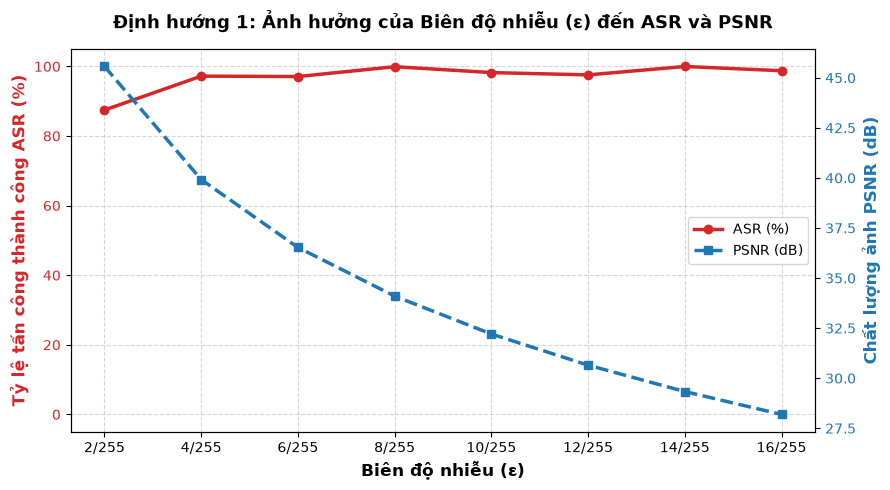

In [ ]:
## Định hướng 1: Ảnh hưởng của Biên độ nhiễu (ε)
eps_ratios = [2, 4, 6, 8, 10, 12, 14, 16]
eps_values = [e / 255.0 for e in eps_ratios]
eps_labels = [f"{e}/255" for e in eps_ratios]

benign_map = benign_metrics.get("mAP@50", 0.58)

asr_list_eps = []
psnr_list_eps = []

print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 1: THAY ĐỔI EPSILON ===")
for eps, label in zip(eps_values, eps_labels):
    print(f"\n[+] Đang đánh giá với Epsilon = {label}...")
    
    adv_m = evaluate_coco_map(
        detector=detector, coco_root=coco_root, split='val2017',
        max_images=EVAL_SAMPLES, confidence_threshold=0.001,
        attack=tog_vanishing, victim=victim,
        epsilon=eps, step_size=eps/4.0, num_iterations=10
    )
    
    adv_map = adv_m.get("mAP@50", 0.0)
    asr = max(0.0, (1.0 - (adv_map / benign_map)) * 100.0) if benign_map > 0 else 0.0
    
    asr_list_eps.append(asr)
    psnr_list_eps.append(adv_m.get("Avg_PSNR", 0.0))

# --- VẼ BIỂU ĐỒ TRỤC TUNG KÉP ---
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:red'
ax1.set_xlabel('Biên độ nhiễu (ε)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tỷ lệ tấn công thành công ASR (%)', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(eps_labels, asr_list_eps, color=color, marker='o', linewidth=2.5, label='ASR (%)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-5, 105)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Chất lượng ảnh PSNR (dB)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(eps_labels, psnr_list_eps, color=color, marker='s', linestyle='--', linewidth=2.5, label='PSNR (dB)')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Định hướng 1: Ảnh hưởng của Biên độ nhiễu (ε) đến ASR và PSNR', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Định hướng 2: Tốc độ hội tụ theo Số bước lặp (N)
Ô này khảo sát N ∈ {1, 2, 5, 10, 15, 20, 30} với ε = 8/255 cố định.

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 2: BƯỚC LẶP N ===

[+] Đang đánh giá với Số bước lặp N = 1...
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.34s).
Accumulating evaluation results...
DONE (t=0.17s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.165
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.320
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.144
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.094
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.232
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.260
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.164
 Average Recal

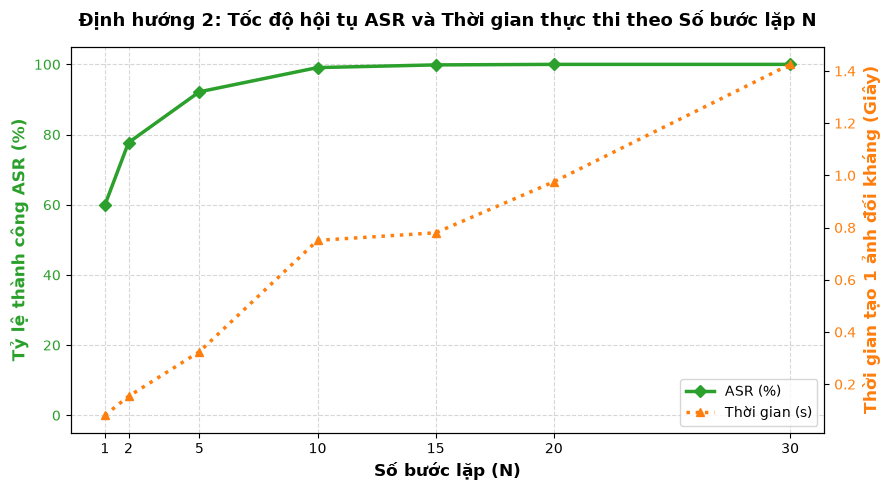

In [ ]:
## Định hướng 2: Tốc độ hội tụ theo Số bước lặp (N)
iterations_list = [1, 2, 5, 10, 15, 20, 30]
fixed_eps = 8 / 255.0

asr_list_iter = []
time_list_iter = []

print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 2: BƯỚC LẶP N ===")
for N in iterations_list:
    print(f"\n[+] Đang đánh giá với Số bước lặp N = {N}...")
    
    adv_m = evaluate_coco_map(
        detector=detector, coco_root=coco_root, split='val2017',
        max_images=EVAL_SAMPLES, confidence_threshold=0.001,
        attack=tog_vanishing, victim=victim,
        epsilon=fixed_eps, step_size=2/255., num_iterations=N
    )
    
    adv_map = adv_m.get("mAP@50", 0.0)
    asr = max(0.0, (1.0 - (adv_map / benign_map)) * 100.0) if benign_map > 0 else 0.0
    
    asr_list_iter.append(asr)
    time_list_iter.append(adv_m.get("Avg_Time", 0.0))

# --- VẼ BIỂU ĐỒ HỘI TỤ ---
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:green'
ax1.set_xlabel('Số bước lặp (N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tỷ lệ thành công ASR (%)', color=color, fontsize=12, fontweight='bold')
l1 = ax1.plot(iterations_list, asr_list_iter, color=color, marker='D', linewidth=2.5, label='ASR (%)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-5, 105)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Thời gian tạo 1 ảnh đối kháng (Giây)', color=color, fontsize=12, fontweight='bold')
l2 = ax2.plot(iterations_list, time_list_iter, color=color, marker='^', linestyle=':', linewidth=2.5, label='Thời gian (s)')
ax2.tick_params(axis='y', labelcolor=color)

plt.xticks(iterations_list)
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right')

plt.title('Định hướng 2: Tốc độ hội tụ ASR và Thời gian thực thi theo Số bước lặp N', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Định hướng 3: So sánh So kè 4 Phương pháp TOG
So sánh tog_vanishing, tog_fabrication, tog_mislabeling, và tog_untargeted trong cùng điều kiện ε = 8/255, N = 10.

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 3: SO SÁNH 4 THUẬT TOÁN TOG ===

[+] Đang chạy thử nghiệm phương pháp: TOG-Vanishing...
loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.14s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  

,Phương pháp,ASR (%),ΔmAP@50,PSNR (dB),Thời gian (s)
0,TOG-Vanishing,99.936959,0.798091,34.100169,0.471670
1,TOG-Fabrication,92.762161,0.740793,33.986572,0.483068
2,TOG-Mislabeling,73.775505,0.589167,34.152137,0.606948
3,TOG-Untargeted,86.618358,0.691729,34.005819,0.621827


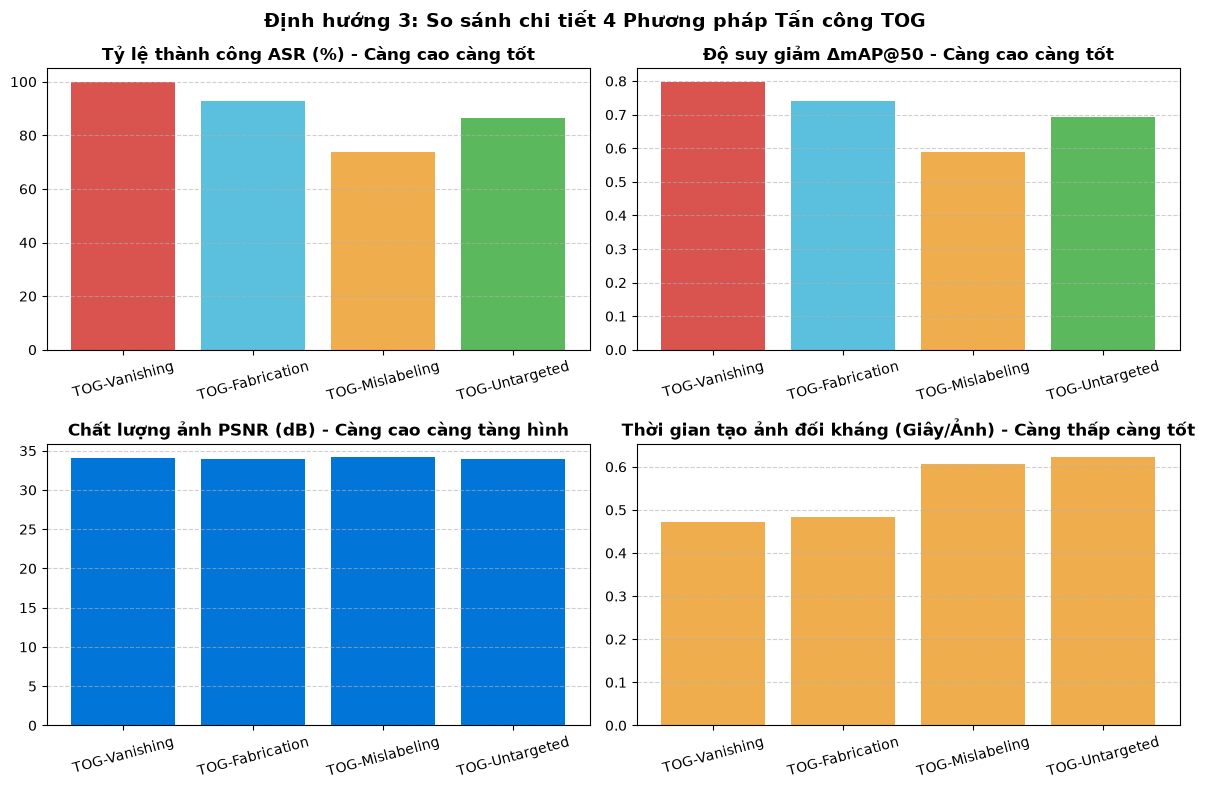

In [20]:
## Định hướng 3: So sánh 4 Phương pháp TOG
methods = [
    ('TOG-Vanishing', lambda victim, image, **kw: tog_vanishing(victim=victim, image=image, **kw)),
    ('TOG-Fabrication', lambda victim, image, **kw: tog_fabrication(victim=victim, image=image, **kw)),
    ('TOG-Mislabeling', lambda victim, image, **kw: tog_mislabeling(victim=victim, image=image, target="most_likely", **kw)),
    ('TOG-Untargeted', lambda victim, image, **kw: tog_untargeted(victim=victim, image=image, **kw))
]

results_d3 = []
benign_map = benign_metrics.get("mAP@50", 0.58)

print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 3: SO SÁNH 4 THUẬT TOÁN TOG ===")


for name, attack_fn in methods:
    print(f"\n[+] Đang chạy thử nghiệm phương pháp: {name}...")
    
    adv_m = evaluate_coco_map(
        detector=detector, coco_root=coco_root, split='val2017',
        max_images=EVAL_SAMPLES, confidence_threshold=0.001,
        attack=attack_fn, victim=victim,
        epsilon=8/255., step_size=2/255., num_iterations=10
    )
    
    adv_map = adv_m.get("mAP@50", 0.0)
    delta_map = abs(adv_map - benign_map)
    asr = max(0.0, (1.0 - (adv_map / benign_map)) * 100.0) if benign_map > 0 else 0.0
    
    results_d3.append({
        'Phương pháp': name,
        'ASR (%)': asr,
        'ΔmAP@50': delta_map,
        'PSNR (dB)': adv_m.get("Avg_PSNR", 0.0),
        'Thời gian (s)': adv_m.get("Avg_Time", 0.0)
    })

df_d3 = pd.DataFrame(results_d3)

# --- ĐIỂM SỬA QUAN TRỌNG: Thay thế inf thành 100 dB để plot không bị lỗi ---
df_d3['PSNR (dB)'] = df_d3['PSNR (dB)'].replace([np.inf, -np.inf], 100.0)

display(df_d3)

# --- VẼ BIỂU ĐỒ SO SÁNH ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(df_d3['Phương pháp'], df_d3['ASR (%)'], color=['#d9534f', '#5bc0de', '#f0ad4e', '#5cb85c'])
axes[0, 0].set_title('Tỷ lệ thành công ASR (%) - Càng cao càng tốt', fontweight='bold')
axes[0, 0].set_ylim(0, 105)

axes[0, 1].bar(df_d3['Phương pháp'], df_d3['ΔmAP@50'], color=['#d9534f', '#5bc0de', '#f0ad4e', '#5cb85c'])
axes[0, 1].set_title('Độ suy giảm ΔmAP@50 - Càng cao càng tốt', fontweight='bold')

axes[1, 0].bar(df_d3['Phương pháp'], df_d3['PSNR (dB)'], color=['#0275d8']*4)
axes[1, 0].set_title('Chất lượng ảnh PSNR (dB) - Càng cao càng tàng hình', fontweight='bold')

axes[1, 1].bar(df_d3['Phương pháp'], df_d3['Thời gian (s)'], color=['#f0ad4e']*4)
axes[1, 1].set_title('Thời gian tạo ảnh đối kháng (Giây/Ảnh) - Càng thấp càng tốt', fontweight='bold')

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Định hướng 3: So sánh chi tiết 4 Phương pháp Tấn công TOG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Định hướng 4: Độ nhạy tấn công theo Kích thước vật thể (Object Size)
Đánh giá xem nhóm vật thể Small (<32² px), Medium, hay Large (>96² px) bị biến mất dễ nhất dưới tác động của TOG-vanishing.

=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 4: KÍCH THƯỚC VẬT THỂ ===
loading annotations into memory...
Done (t=0.36s)
creating index...
index created!
Đang xử lý đánh giá trên 50 ảnh...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.13s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.032
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= 

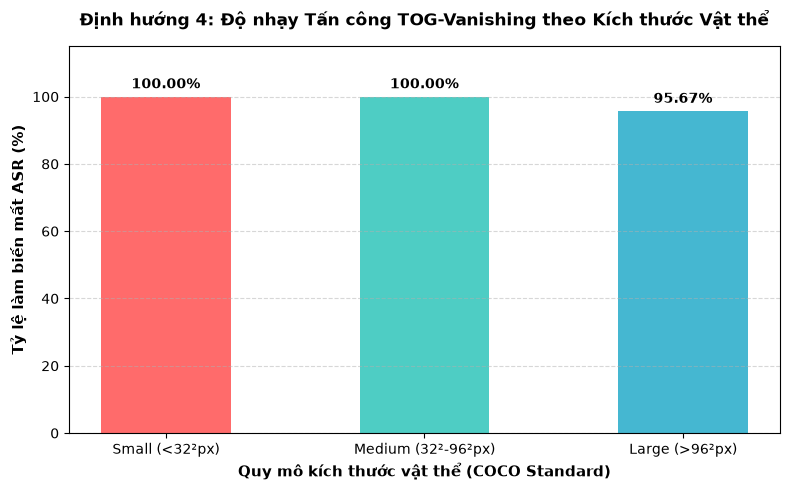

In [ ]:
## Định hướng 4: Độ nhạy tấn công theo Kích thước vật thể (Object Size)
print("=== BẮT ĐẦU THỬ NGHIỆM ĐỊNH HƯỚNG 4: KÍCH THƯỚC VẬT THỂ ===")

adv_metrics_vanish = evaluate_coco_map(
    detector=detector, coco_root=coco_root, split='val2017',
    max_images=EVAL_SAMPLES, confidence_threshold=0.001,
    attack=tog_vanishing, victim=victim,
    epsilon=8/255., step_size=2/255., num_iterations=10
)

categories = ['Small (<32²px)', 'Medium (32²-96²px)', 'Large (>96²px)']
metric_keys = ['mAP (Small)', 'mAP (Medium)', 'mAP (Large)']

asr_by_size = []
for key in metric_keys:
    b_val = benign_metrics.get(key, 0.0)
    a_val = adv_metrics_vanish.get(key, 0.0)
    
    asr = max(0.0, (1.0 - (a_val / b_val)) * 100.0) if b_val > 0 else 0.0
    asr_by_size.append(asr)

# --- VẼ BIỂU ĐỒ CỘT ---
plt.figure(figsize=(8, 5))
bars = plt.bar(categories, asr_by_size, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Định hướng 4: Độ nhạy Tấn công TOG-Vanishing theo Kích thước Vật thể', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Quy mô kích thước vật thể (COCO Standard)', fontsize=11, fontweight='bold')
plt.ylabel('Tỷ lệ làm biến mất ASR (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

CODE THÊM VIDEO SAMPLE

In [ ]:
import urllib.request

# Tải sample video giao thông chuẩn từ Intel IoT DevKit (khoảng 10MB)
url = "https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/person-bicycle-car-detection.mp4"
output_path = "sample_video.mp4"

print("Đang tải sample video...")
urllib.request.urlretrieve(url, output_path)
print(f"[SUCCESS] Đã tải xong file: {output_path}")

Đang tải sample video...
[SUCCESS] Đã tải xong file: sample_video.mp4


Code XỬ LÝ VIDEO

In [ ]:
import cv2
import inspect
import numpy as np
import torch
from PIL import Image
from pathlib import Path
from utils import letterbox_image

# Danh sách 80 nhãn vật thể chuẩn của YOLO/COCO
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

# ---------------------------------------------------------------------
# HÀM BÓC TÁCH & GỘP MẢNG
# ---------------------------------------------------------------------
def parse_detection(det, img_w, img_h):
    try:
        det = np.array(det).flatten()
        if len(det) < 6: return None
            
        class_id = int(det[0])
        score = float(det[1])
        x1, y1, x2, y2 = float(det[-4]), float(det[-3]), float(det[-2]), float(det[-1])
        
        if max(abs(x1), abs(y1), abs(x2), abs(y2)) <= 2.0:
            x1 *= img_w; x2 *= img_w; y1 *= img_h; y2 *= img_h
            
        xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
        ymin, ymax = int(min(y1, y2)), int(max(y1, y2))
        
        xmin, xmax = max(0, min(xmin, img_w)), max(0, min(xmax, img_w))
        ymin, ymax = max(0, min(ymin, img_h)), max(0, min(ymax, img_h))
        
        return class_id, score, xmin, ymin, xmax, ymax
    except Exception:
        return None

def format_detections(dets):
    if dets is None: return []
    if isinstance(dets, torch.Tensor): dets = dets.detach().cpu().numpy()
    if isinstance(dets, (list, tuple)) and len(dets) > 0 and isinstance(dets[0], (list, tuple, np.ndarray, torch.Tensor)):
        dets = dets[0]
        if isinstance(dets, torch.Tensor): dets = dets.detach().cpu().numpy()
    dets = np.asarray(dets)
    if dets.size == 0: return []
    if dets.ndim == 3: dets = dets[0]
    elif dets.ndim == 1 and dets.size >= 5: dets = dets[np.newaxis, :]
    return dets

# ---------------------------------------------------------------------
# HÀM VẼ GIAO DIỆN (UI)
# ---------------------------------------------------------------------
def draw_bbox_with_label(img, xmin, ymin, xmax, ymax, class_id, score, bg_color):
    class_name = COCO_CLASSES[class_id] if class_id < len(COCO_CLASSES) else f"Obj_{class_id}"
    class_name = class_name.capitalize()
    
    label = f"{class_name}: {score*100:.0f}%"

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), bg_color, 2)
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.45
    thickness = 1
    (text_width, text_height), baseline = cv2.getTextSize(label, font, font_scale, thickness)
    
    text_ymin = max(ymin, text_height + 5)
    
    cv2.rectangle(img, (xmin, text_ymin - text_height - 5), 
                  (xmin + text_width, text_ymin + baseline - 5), bg_color, -1)
    
    text_color = (0, 0, 0) if bg_color == (0, 255, 0) else (255, 255, 255)
    cv2.putText(img, label, (xmin, text_ymin - 5), font, font_scale, text_color, thickness, cv2.LINE_AA)

# ---------------------------------------------------------------------
# 1. HÀM SAFE_TOG_ATTACK
# ---------------------------------------------------------------------
def safe_tog_attack(attack_fn, victim, image, epsilon=8/255., step_size=2/255., num_iterations=10, detector=None, **kwargs):
    try:
        sig = inspect.signature(attack_fn)
        params = sig.parameters
        attack_args = {}
        
        if 'victim' in params: attack_args['victim'] = victim
        if 'x_query' in params: attack_args['x_query'] = image
        elif 'image' in params: attack_args['image'] = image
        elif 'x' in params: attack_args['x'] = image
        if 'eps' in params: attack_args['eps'] = float(epsilon)
        elif 'epsilon' in params: attack_args['epsilon'] = float(epsilon)
        if 'eps_step' in params: attack_args['eps_step'] = float(step_size)
        elif 'step_size' in params: attack_args['step_size'] = float(step_size)
        if 'n_iter' in params: attack_args['n_iter'] = int(num_iterations)
        elif 'num_iterations' in params: attack_args['num_iterations'] = int(num_iterations)
        if 'confidence_threshold' in params: attack_args['confidence_threshold'] = 0.1
        if 'mode' in params: attack_args['mode'] = 'most_likely'

        if 'target' in params:
            try:
                dets = format_detections(victim.detect(image, confidence_threshold=0.1))
            except:
                dets = np.empty((0, 6))
            attack_args['target'] = dets
        return attack_fn(**attack_args)
    except Exception:
        return image

# ---------------------------------------------------------------------
# 2. HÀM XỬ LÝ VIDEO ĐÃ THÊM ĐẾM TIẾN ĐỘ & VẬT THỂ
# ---------------------------------------------------------------------
def process_and_attack_video_side_by_side(
    input_video_path, output_video_path, detector, victim, attack_fn, 
    epsilon=8/255., step_size=2/255., num_iterations=10, conf_thresh=0.20, max_frames=None
):
    input_path = Path(input_video_path)
    cap = cv2.VideoCapture(str(input_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames_in_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Tính toán tổng số frame sẽ thực sự chạy để hiển thị tiến độ chính xác
    target_frames = total_frames_in_video if max_frames is None else min(max_frames, total_frames_in_video)
    target_frames = max(1, target_frames) # Tránh chia cho 0

    frame_h, frame_w = detector.model_image_size
    out_width = frame_w * 2
    out_height = frame_h

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_video_path), fourcc, fps, (out_width, out_height))

    frame_idx = 0

    while cap.isOpened():
        ret, frame_bgr = cap.read()
        if not ret or (max_frames and frame_idx >= max_frames): break
        frame_idx += 1

        # Hiển thị tiến độ rõ ràng: frame hiện tại / tổng frame (Phần trăm %)
        progress_pct = (frame_idx / target_frames) * 100
        print(f"  • Tiến độ: {frame_idx}/{target_frames} frames ({progress_pct:.1f}%)", end='\r')

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(frame_rgb)
        x_clean, _ = letterbox_image(pil_img, size=(frame_w, frame_h))

        x_adv = safe_tog_attack(attack_fn, victim, x_clean, epsilon, step_size, num_iterations, detector)

        def to_numpy_img(x):
            arr = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)
            arr = np.squeeze(arr)
            if arr.ndim == 3 and arr.shape[0] in [1, 3]: arr = np.transpose(arr, (1, 2, 0))
            return (np.clip(arr, 0, 1) * 255).astype(np.uint8)

        clean_img_draw = np.ascontiguousarray(to_numpy_img(x_clean).copy())
        adv_img_draw = np.ascontiguousarray(to_numpy_img(x_adv).copy())

        raw_clean = detector.detect(x_clean, confidence_threshold=conf_thresh)
        raw_adv = detector.detect(x_adv, confidence_threshold=conf_thresh)

        dets_clean = format_detections(raw_clean)
        dets_adv = format_detections(raw_adv)

        # Biến đếm số lượng vật thể trên 2 khung hình
        count_clean = 0
        count_adv = 0

        # Vẽ và đếm vật thể trên khung Clean
        for det in dets_clean:
            parsed = parse_detection(det, frame_w, frame_h)
            if parsed:
                class_id, score, xmin, ymin, xmax, ymax = parsed
                if (xmax - xmin) > 2 and (ymax - ymin) > 2:
                    draw_bbox_with_label(clean_img_draw, xmin, ymin, xmax, ymax, class_id, score, (0, 255, 0))
                    count_clean += 1

        # Vẽ và đếm vật thể trên khung Adv
        for det in dets_adv:
            parsed = parse_detection(det, frame_w, frame_h)
            if parsed:
                class_id, score, xmin, ymin, xmax, ymax = parsed
                if (xmax - xmin) > 2 and (ymax - ymin) > 2:
                    draw_bbox_with_label(adv_img_draw, xmin, ymin, xmax, ymax, class_id, score, (255, 0, 0))
                    count_adv += 1

        # Vẽ tiêu đề và SỐ LƯỢNG VẬT THỂ đếm được
        cv2.putText(clean_img_draw, "BENIGN", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
        cv2.putText(clean_img_draw, f"Objects: {count_clean}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

        cv2.putText(adv_img_draw, f"ATTACK ({attack_fn.__name__})", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)
        cv2.putText(adv_img_draw, f"Objects: {count_adv}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2, cv2.LINE_AA)

        out.write(cv2.cvtColor(np.hstack((clean_img_draw, adv_img_draw)), cv2.COLOR_RGB2BGR))

    cap.release()
    out.release()
    print("\n[SUCCESS] Đã hoàn thành render video với thanh tiến độ và số lượng vật thể!")

TEST TRÊN FILE VIDEO

In [ ]:
INPUT_VIDEO = "sample_video.mp4"         # Tên file video đầu vào
OUTPUT_VIDEO = "output_side_by_side.mp4" # File video kết quả ghép 2 bên

process_and_attack_video_side_by_side(
    input_video_path=INPUT_VIDEO,
    output_video_path=OUTPUT_VIDEO,
    detector=detector,
    victim=victim,
    attack_fn=tog_vanishing,
    epsilon=8/255.,
    step_size=2/255.,
    num_iterations=10,
    max_frames=None # Bỏ giới hạn, chương trình sẽ tự chạy hết toàn bộ video từ đầu tới cuối
)

  • Tiến độ: 647 frames
[SUCCESS] Đã hoàn thành render video với nhãn tên (Person, Car...)!
